In [2]:
import pandas as pd
import numpy as np

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
CSV_PATH= "/kaggle/input/renewable-energy-microgrid-dataset/Renewable_energy_dataset.csv"
DATE_COL= "timestamp"

In [5]:
def load_data(path):
    df = pd.read_csv(path, parse_dates=[DATE_COL])
    df = df.sort_values(DATE_COL).reset_index(drop=True)
    return df

df = load_data(CSV_PATH)
print(df.shape)

(3546, 21)


In [6]:
df.columns

Index(['timestamp', 'solar_pv_output', 'wind_power_output',
       'total_renewable_energy', 'solar_irradiance', 'wind_speed',
       'temperature', 'humidity', 'atmospheric_pressure', 'grid_load_demand',
       'frequency', 'voltage', 'power_exchange', 'battery_state_of_charge',
       'battery_charging_rate', 'battery_discharging_rate', 'hour_of_day',
       'day_of_week', 'predicted_solar_pv_output',
       'predicted_wind_power_output', 'total_predicted_energy'],
      dtype='object')

In [7]:
df = df.drop(columns=[
    "predicted_solar_pv_output",
    "predicted_wind_power_output",
    "total_predicted_energy"
])

In [8]:
df.columns

Index(['timestamp', 'solar_pv_output', 'wind_power_output',
       'total_renewable_energy', 'solar_irradiance', 'wind_speed',
       'temperature', 'humidity', 'atmospheric_pressure', 'grid_load_demand',
       'frequency', 'voltage', 'power_exchange', 'battery_state_of_charge',
       'battery_charging_rate', 'battery_discharging_rate', 'hour_of_day',
       'day_of_week'],
      dtype='object')

In [9]:
df.describe()

,timestamp,solar_pv_output,wind_power_output,total_renewable_energy,solar_irradiance,wind_speed,temperature,humidity,atmospheric_pressure,grid_load_demand,frequency,voltage,power_exchange,battery_state_of_charge,battery_charging_rate,battery_discharging_rate,hour_of_day,day_of_week
count,3546,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000
mean,2023-03-15 20:30:00,49.909364,49.371067,99.280431,593.997616,12.455912,15.339873,55.747012,1001.088660,271.080951,49.994672,229.968267,-0.364718,49.980993,24.800937,24.738515,11.484772,3.015228
min,2023-01-01 00:00:00,0.001163,0.003072,2.065235,200.042262,0.003944,-9.987377,10.055047,950.004812,50.049604,49.000135,220.000111,-99.963992,0.064887,0.000837,0.005236,0.000000,0.000000
25%,2023-02-06 22:15:00,24.550367,24.350398,70.623850,401.525995,6.088757,2.909381,33.724489,976.254480,159.185954,49.493826,224.911214,-49.867832,24.962208,12.109388,12.140934,5.000000,1.000000
50%,2023-03-15 20:30:00,50.554464,48.575995,99.500878,593.145326,12.235414,15.717948,55.666805,1001.599469,271.269674,49.989590,230.086512,-0.075666,49.389784,24.628500,24.573502,11.000000,3.000000
75%,2023-04-21 18:45:00,75.045551,74.376711,128.412283,784.797592,18.914590,27.863543,77.915407,1025.843757,379.377400,50.501932,234.734112,49.874833,75.816349,37.354485,37.525802,17.000000,5.000000
max,2023-05-28 17:00:00,99.971767,99.955770,197.692063,999.604152,24.991830,39.996241,99.991088,1049.965631,499.863024,50.999464,239.995787,99.853737,99.989056,49.998607,49.997848,23.000000,6.000000
std,NaN,29.091886,28.782146,41.285153,227.273496,7.290605,14.399727,25.997578,28.762635,128.923760,0.576677,5.724512,57.866406,29.093383,14.400444,14.491033,6.918744,2.006560


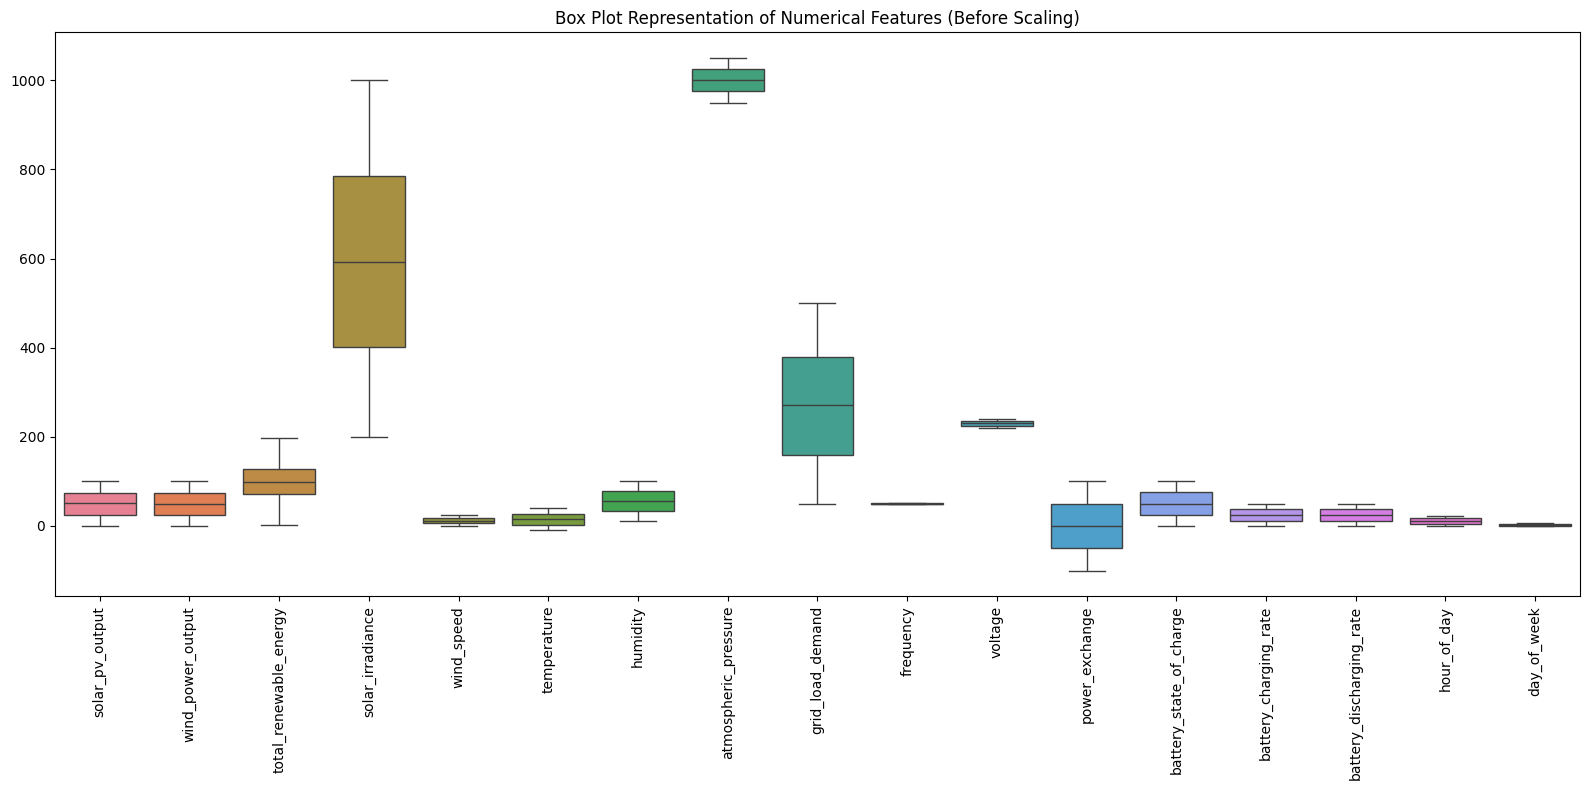

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,8))

sns.boxplot(data=df.drop(columns=['timestamp']))
plt.xticks(rotation=90)

plt.title("Box Plot Representation of Numerical Features (Before Scaling)")
plt.tight_layout()
plt.show()

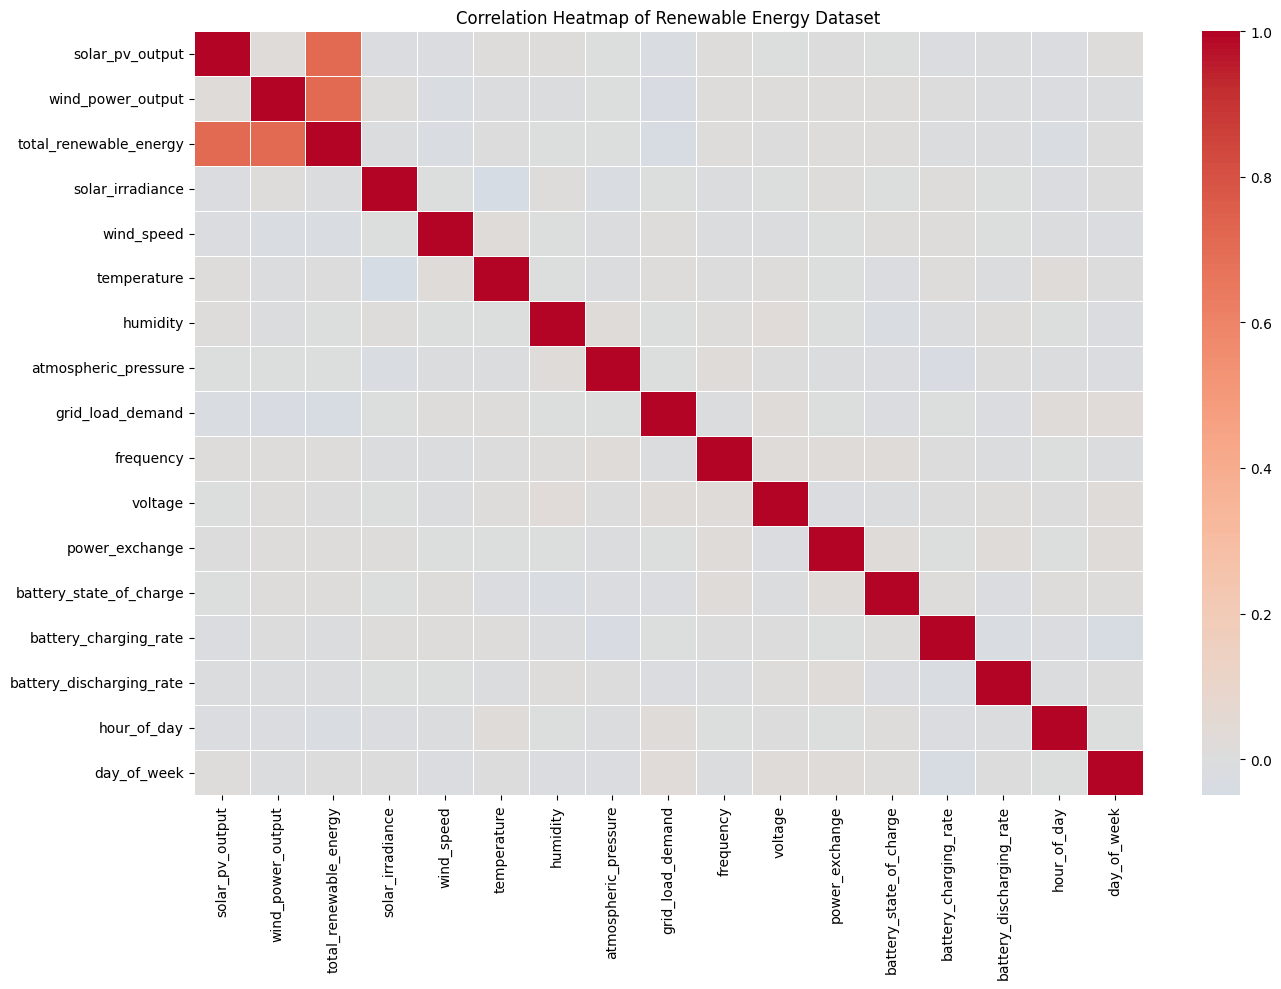

In [13]:
plt.figure(figsize=(14,10))

corr_matrix = df.drop(columns=['timestamp']).corr()

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Renewable Energy Dataset")
plt.tight_layout()
plt.show()

In [23]:
corr_abs = corr_matrix.abs()
np.fill_diagonal(corr_abs.values, 0)
(
    corr_abs.unstack()
    .sort_values(ascending=False)
    .drop_duplicates()
    .head(15)
)


solar_pv_output          total_renewable_energy     0.717027
total_renewable_energy   wind_power_output          0.709658
temperature              solar_irradiance           0.049611
total_renewable_energy   grid_load_demand           0.043213
battery_charging_rate    day_of_week                0.041046
grid_load_demand         wind_power_output          0.036970
battery_charging_rate    atmospheric_pressure       0.029657
voltage                  humidity                   0.028682
grid_load_demand         day_of_week                0.027001
battery_state_of_charge  humidity                   0.025949
wind_speed               total_renewable_energy     0.025833
grid_load_demand         solar_pv_output            0.024749
wind_speed               wind_power_output          0.024194
frequency                battery_state_of_charge    0.023742
total_renewable_energy   hour_of_day                0.023097
dtype: float64

In [26]:
df['timestamp']

0      2023-01-01 00:00:00
1      2023-01-01 01:00:00
2      2023-01-01 02:00:00
3      2023-01-01 03:00:00
4      2023-01-01 04:00:00
               ...        
3541   2023-05-28 13:00:00
3542   2023-05-28 14:00:00
3543   2023-05-28 15:00:00
3544   2023-05-28 16:00:00
3545   2023-05-28 17:00:00
Name: timestamp, Length: 3546, dtype: datetime64[ns]

In [27]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')

df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['month'] = df['timestamp'].dt.month
df['weekofyear'] = df['timestamp'].dt.isocalendar().week.astype(int)

# Cyclical encoding
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)


In [28]:
df.head(5)

,timestamp,solar_pv_output,wind_power_output,total_renewable_energy,solar_irradiance,wind_speed,temperature,humidity,atmospheric_pressure,grid_load_demand,...,hour_of_day,day_of_week,hour,day,month,weekofyear,hour_sin,hour_cos,dow_sin,dow_cos
0,2023-01-01 00:00:00,37.454012,8.273684,45.727695,751.423457,18.770285,18.094905,53.215610,1004.872349,294.401249,...,0,6,0,1,1,52,0.000000,1.000000,-0.781831,0.62349
1,2023-01-01 01:00:00,95.071431,48.453800,143.525230,301.682091,6.638605,11.669042,63.906997,1009.493484,185.824084,...,1,6,1,1,1,52,0.258819,0.965926,-0.781831,0.62349
2,2023-01-01 02:00:00,73.199394,30.241951,103.441345,485.378535,14.296742,12.945826,26.234179,970.753014,347.363574,...,2,6,2,1,1,52,0.500000,0.866025,-0.781831,0.62349
3,2023-01-01 03:00:00,59.865848,56.340836,116.206685,673.986395,22.357572,38.478603,53.165238,970.833286,193.641771,...,3,6,3,1,1,52,0.707107,0.707107,-0.781831,0.62349
4,2023-01-01 04:00:00,15.601864,80.380489,95.982353,868.457364,11.879943,4.807723,69.228330,977.621817,244.023572,...,4,6,4,1,1,52,0.866025,0.500000,-0.781831,0.62349


In [29]:
df.columns

Index(['timestamp', 'solar_pv_output', 'wind_power_output',
       'total_renewable_energy', 'solar_irradiance', 'wind_speed',
       'temperature', 'humidity', 'atmospheric_pressure', 'grid_load_demand',
       'frequency', 'voltage', 'power_exchange', 'battery_state_of_charge',
       'battery_charging_rate', 'battery_discharging_rate', 'hour_of_day',
       'day_of_week', 'hour', 'day', 'month', 'weekofyear', 'hour_sin',
       'hour_cos', 'dow_sin', 'dow_cos'],
      dtype='object')

**LSTM**

### **LightGBM (Light Gradient Boosting Machine)**

In [30]:
def create_lag_rolling_features(df, target, lags, windows):
    df = df.copy()

    # Lag features
    for lag in lags:
        df[f'{target}_lag_{lag}'] = df[target].shift(lag)

    # Rolling statistics
    for w in windows:
        df[f'{target}_roll_mean_{w}'] = df[target].shift(1).rolling(w).mean()
        df[f'{target}_roll_std_{w}']  = df[target].shift(1).rolling(w).std()

    return df

In [31]:
LAGS = [1, 2, 3, 6, 12, 24]
WINDOWS = [3, 6, 12, 24]
SOLAR_TARGET = 'solar_pv_output'

**Solar**

In [32]:
solar_df = create_lag_rolling_features(
    df,
    target=SOLAR_TARGET,
    lags=LAGS,
    windows=WINDOWS
)

solar_df = solar_df.dropna()

In [33]:
solar_df.columns

Index(['timestamp', 'solar_pv_output', 'wind_power_output',
       'total_renewable_energy', 'solar_irradiance', 'wind_speed',
       'temperature', 'humidity', 'atmospheric_pressure', 'grid_load_demand',
       'frequency', 'voltage', 'power_exchange', 'battery_state_of_charge',
       'battery_charging_rate', 'battery_discharging_rate', 'hour_of_day',
       'day_of_week', 'hour', 'day', 'month', 'weekofyear', 'hour_sin',
       'hour_cos', 'dow_sin', 'dow_cos', 'solar_pv_output_lag_1',
       'solar_pv_output_lag_2', 'solar_pv_output_lag_3',
       'solar_pv_output_lag_6', 'solar_pv_output_lag_12',
       'solar_pv_output_lag_24', 'solar_pv_output_roll_mean_3',
       'solar_pv_output_roll_std_3', 'solar_pv_output_roll_mean_6',
       'solar_pv_output_roll_std_6', 'solar_pv_output_roll_mean_12',
       'solar_pv_output_roll_std_12', 'solar_pv_output_roll_mean_24',
       'solar_pv_output_roll_std_24'],
      dtype='object')

In [34]:
solar_features = [
    'solar_irradiance',
    'wind_speed',
    'temperature',
    'humidity',
    'atmospheric_pressure',
    'grid_load_demand',
       'frequency', 'voltage', 'power_exchange', 'battery_state_of_charge',
       'battery_charging_rate', 'battery_discharging_rate',
    'hour_sin',
    'hour_cos',
    'dow_sin',
    'dow_cos'
] + [col for col in solar_df.columns if SOLAR_TARGET in col]


In [35]:
solar_features

['solar_irradiance',
 'wind_speed',
 'temperature',
 'humidity',
 'atmospheric_pressure',
 'grid_load_demand',
 'frequency',
 'voltage',
 'power_exchange',
 'battery_state_of_charge',
 'battery_charging_rate',
 'battery_discharging_rate',
 'hour_sin',
 'hour_cos',
 'dow_sin',
 'dow_cos',
 'solar_pv_output',
 'solar_pv_output_lag_1',
 'solar_pv_output_lag_2',
 'solar_pv_output_lag_3',
 'solar_pv_output_lag_6',
 'solar_pv_output_lag_12',
 'solar_pv_output_lag_24',
 'solar_pv_output_roll_mean_3',
 'solar_pv_output_roll_std_3',
 'solar_pv_output_roll_mean_6',
 'solar_pv_output_roll_std_6',
 'solar_pv_output_roll_mean_12',
 'solar_pv_output_roll_std_12',
 'solar_pv_output_roll_mean_24',
 'solar_pv_output_roll_std_24']

In [36]:
split_date = solar_df['timestamp'].quantile(0.8)

train_solar = solar_df[solar_df['timestamp'] <= split_date]
test_solar  = solar_df[solar_df['timestamp'] > split_date]

X_train_solar = train_solar[solar_features]
y_train_solar = train_solar[SOLAR_TARGET]

X_test_solar = test_solar[solar_features]
y_test_solar = test_solar[SOLAR_TARGET]


In [37]:
print(f"Training set: {X_train_solar.shape,y_train_solar.shape}")
print(f"Testing set: {X_test_solar.shape,y_test_solar.shape}")

Training set: ((2817, 31), (2817,))
Testing set: ((705, 31), (705,))


In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler_solar = StandardScaler()

X_train_scaled_solar = scaler_solar.fit_transform(X_train_solar)
X_test_scaled_solar  = scaler_solar.transform(X_test_solar)

In [39]:
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled_solar)
X_test_pca  = pca.transform(X_test_scaled_solar)


In [40]:
X_train_pca

array([[-3.30488788e+00, -1.85137032e+00,  5.96376624e-01, ...,
         1.30464854e-01,  3.74072711e-01, -9.05646988e-16],
       [-3.21038553e+00, -2.91298503e+00, -9.90052061e-01, ...,
         4.55352147e-01,  1.13021851e-01, -6.09500700e-16],
       [-1.56333063e+00, -1.89744408e+00, -1.52338633e+00, ...,
         1.79842012e-02, -2.43130067e-01, -3.49147008e-16],
       ...,
       [ 4.26259532e-01,  2.73788613e+00, -1.69929705e+00, ...,
        -3.07648642e-02,  3.19073175e-02,  1.16604018e-15],
       [ 5.83612692e-01,  2.59869223e+00, -1.96169803e+00, ...,
         4.83108223e-01,  3.85407332e-01,  3.46706911e-16],
       [-4.45817395e-01,  1.98825917e+00, -5.19848891e-01, ...,
         1.06385327e+00,  7.99929528e-01, -1.96051664e-16]])

In [41]:
loadings = pca.components_.T    # shape: (features, components)
explained = pca.explained_variance_ratio_

# Importance score for each feature
feature_importance = np.sum(np.abs(loadings) * explained, axis=1)

# Put into a dataframe
pca_feature_importance = pd.DataFrame({
    "feature": solar_features,
    "importance": feature_importance
}).sort_values(by="importance", ascending=False)

pca_feature_importance

,feature,importance
18,solar_pv_output_lag_2,0.151919
17,solar_pv_output_lag_1,0.148810
19,solar_pv_output_lag_3,0.147483
13,hour_cos,0.141211
15,dow_cos,0.138396
16,solar_pv_output,0.137991
8,power_exchange,0.137834
14,dow_sin,0.137478
22,solar_pv_output_lag_24,0.136090
5,grid_load_demand,0.134111


In [ ]:
import lightgbm as lgb

solar_model = lgb.LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=8,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

solar_model.fit(
    X_train_scaled_solar,
    y_train_solar,
    eval_set=[(X_test_scaled_solar, y_test_solar)],
    eval_metric='rmse',
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(100)
    ]
)


In [43]:
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score

y_pred_solar = solar_model.predict(X_test_scaled_solar)

mse = mean_squared_error(y_test_solar, y_pred_solar)
rmse = np.sqrt(mean_squared_error(y_test_solar, y_pred_solar))
mae = mean_absolute_error(y_test_solar, y_pred_solar)

from sklearn.metrics import r2_score

print("Accuracy:",r2_score(y_test_solar, y_pred_solar))
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE :", mae)


Accuracy: 0.9983108204197189
MSE: 1.3965367800542166
RMSE: 1.181751572901097
MAE : 0.9346581306296775


In [44]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

xgb_model.fit(X_train_solar, y_train_solar)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1500,
             n_jobs=None, num_parallel_tree=None, ...)

In [45]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.03,
    depth=8,
    loss_function='RMSE',
    verbose=200
)

cat_model.fit(X_train_solar, y_train_solar)


0:	learn: 28.4440037	total: 78.4ms	remaining: 1m 57s
200:	learn: 0.6018549	total: 2.65s	remaining: 17.1s
400:	learn: 0.3935835	total: 5.28s	remaining: 14.5s
600:	learn: 0.2985802	total: 7.88s	remaining: 11.8s
800:	learn: 0.2315805	total: 10.4s	remaining: 9.11s
1000:	learn: 0.1804654	total: 13s	remaining: 6.49s
1200:	learn: 0.1416782	total: 15.7s	remaining: 3.9s
1400:	learn: 0.1129462	total: 18.3s	remaining: 1.29s
1499:	learn: 0.1002408	total: 19.6s	remaining: 0us


In [46]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_solar, y_train_solar)


RandomForestRegressor(max_depth=15, min_samples_leaf=5, n_estimators=500,
                      n_jobs=-1, random_state=42)

In [47]:
from sklearn.svm import SVR

svr_model = SVR(
    kernel='rbf',
    C=10,
    epsilon=0.1
)

svr_model.fit(X_train_pca, y_train_solar)


SVR(C=10)

In [48]:
from sklearn.linear_model import ElasticNet

enet = ElasticNet(alpha=0.01, l1_ratio=0.5)
enet.fit(X_train_scaled_solar, y_train_solar)


ElasticNet(alpha=0.01)

In [49]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

def evaluate_regression_model(
    model,
    X_test,
    y_test,
    model_name=None
):
    y_pred = model.predict(X_test)

    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    results = {
        "Model": model_name if model_name else model.__class__.__name__,
        "R2": r2,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae
    }

    return results


In [50]:
results = []

results.append(
    evaluate_regression_model(
        solar_model,
        X_test_scaled_solar,
        y_test_solar,
        "LightGBM"
    )
)

results.append(
    evaluate_regression_model(
        xgb_model,
        X_test_solar,          # XGBoost usually works fine without scaling
        y_test_solar,
        "XGBoost"
    )
)

results.append(
    evaluate_regression_model(
        cat_model,
        X_test_solar,
        y_test_solar,
        "CatBoost"
    )
)

results.append(
    evaluate_regression_model(
        rf_model,
        X_test_solar,
        y_test_solar,
        "Random Forest"
    )
)

results.append(
    evaluate_regression_model(
        svr_model,
        X_test_pca,    # SVR → PCA-reduced input
        y_test_solar,
        "SVR (RBF)"
    )
)

results.append(
    evaluate_regression_model(
        enet,
        X_test_scaled_solar,
        y_test_solar,
        "ElasticNet"
    )
)

results_df = pd.DataFrame(results)
results_df


,Model,R2,MSE,RMSE,MAE
0,LightGBM,0.998311,1.396537,1.181752,0.934658
1,XGBoost,0.994345,4.675008,2.162177,1.798702
2,CatBoost,0.999491,0.420856,0.648734,0.452468
3,Random Forest,0.999998,0.001512,0.038881,0.027037
4,SVR (RBF),0.976295,19.598064,4.426970,3.138439
5,ElasticNet,0.999973,0.021933,0.148099,0.129786


**Wind**

In [51]:
WIND_TARGET = 'wind_power_output'

In [52]:
wind_df = create_lag_rolling_features(
    df,
    target=WIND_TARGET,
    lags=LAGS,
    windows=WINDOWS
)

wind_df = wind_df.dropna()


In [53]:
wind_df.columns

Index(['timestamp', 'solar_pv_output', 'wind_power_output',
       'total_renewable_energy', 'solar_irradiance', 'wind_speed',
       'temperature', 'humidity', 'atmospheric_pressure', 'grid_load_demand',
       'frequency', 'voltage', 'power_exchange', 'battery_state_of_charge',
       'battery_charging_rate', 'battery_discharging_rate', 'hour_of_day',
       'day_of_week', 'hour', 'day', 'month', 'weekofyear', 'hour_sin',
       'hour_cos', 'dow_sin', 'dow_cos', 'wind_power_output_lag_1',
       'wind_power_output_lag_2', 'wind_power_output_lag_3',
       'wind_power_output_lag_6', 'wind_power_output_lag_12',
       'wind_power_output_lag_24', 'wind_power_output_roll_mean_3',
       'wind_power_output_roll_std_3', 'wind_power_output_roll_mean_6',
       'wind_power_output_roll_std_6', 'wind_power_output_roll_mean_12',
       'wind_power_output_roll_std_12', 'wind_power_output_roll_mean_24',
       'wind_power_output_roll_std_24'],
      dtype='object')

In [54]:
wind_features = [
    'wind_speed',
    'temperature',
    'humidity',
    'atmospheric_pressure',
    'grid_load_demand',
       'frequency', 'voltage', 'power_exchange', 'battery_state_of_charge',
       'battery_charging_rate', 'battery_discharging_rate',
    'hour_sin',
    'hour_cos',
    'dow_sin',
    'dow_cos'
] + [col for col in wind_df.columns if WIND_TARGET in col]


In [55]:
wind_features

['wind_speed',
 'temperature',
 'humidity',
 'atmospheric_pressure',
 'grid_load_demand',
 'frequency',
 'voltage',
 'power_exchange',
 'battery_state_of_charge',
 'battery_charging_rate',
 'battery_discharging_rate',
 'hour_sin',
 'hour_cos',
 'dow_sin',
 'dow_cos',
 'wind_power_output',
 'wind_power_output_lag_1',
 'wind_power_output_lag_2',
 'wind_power_output_lag_3',
 'wind_power_output_lag_6',
 'wind_power_output_lag_12',
 'wind_power_output_lag_24',
 'wind_power_output_roll_mean_3',
 'wind_power_output_roll_std_3',
 'wind_power_output_roll_mean_6',
 'wind_power_output_roll_std_6',
 'wind_power_output_roll_mean_12',
 'wind_power_output_roll_std_12',
 'wind_power_output_roll_mean_24',
 'wind_power_output_roll_std_24']

In [56]:
split_date = wind_df['timestamp'].quantile(0.8)

train_wind = wind_df[wind_df['timestamp'] <= split_date]
test_wind  = wind_df[wind_df['timestamp'] > split_date]

X_train_wind = train_wind[wind_features]
y_train_wind = train_wind[WIND_TARGET]

X_test_wind = test_wind[wind_features]
y_test_wind = test_wind[WIND_TARGET]


In [57]:
print(f"Training set: {X_train_wind.shape,y_train_wind.shape}")
print(f"Testing set: {X_test_wind.shape,y_test_wind.shape}")

Training set: ((2817, 30), (2817,))
Testing set: ((705, 30), (705,))


In [58]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler_wind = StandardScaler()

X_train_scaled_wind = scaler_wind.fit_transform(X_train_wind)
X_test_scaled_wind  = scaler_wind.transform(X_test_wind)

In [59]:
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled_wind)
X_test_pca  = pca.transform(X_test_scaled_wind)

In [60]:
loadings = pca.components_.T    # shape: (features, components)
explained = pca.explained_variance_ratio_

# Importance score for each feature
feature_importance = np.sum(np.abs(loadings) * explained, axis=1)

# Put into a dataframe
pca_feature_importance = pd.DataFrame({
    "feature": wind_features,
    "importance": feature_importance
}).sort_values(by="importance", ascending=False)

pca_feature_importance

,feature,importance
18,wind_power_output_lag_3,0.148955
16,wind_power_output_lag_1,0.146566
17,wind_power_output_lag_2,0.142399
15,wind_power_output,0.140323
1,temperature,0.136518
6,voltage,0.135592
0,wind_speed,0.135515
14,dow_cos,0.135179
13,dow_sin,0.134909
4,grid_load_demand,0.133706


In [ ]:
wind_model = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=10,
    num_leaves=96,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

wind_model.fit(
    X_train_scaled_wind,
    y_train_wind,
    eval_set=[(X_test_scaled_wind, y_test_wind)],
    eval_metric='rmse',
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(100)
    ]
)


In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred_wind = wind_model.predict(X_test_scaled_wind)

mse = mean_squared_error(y_test_wind, y_pred_wind)
rmse = np.sqrt(mean_squared_error(y_test_wind, y_pred_wind))
mae = mean_absolute_error(y_test_wind, y_pred_wind)

print("\nWIND MODEL")


print("Accuracy:",r2_score(y_test_wind, y_pred_wind))
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE :", mae)



WIND MODEL
Accuracy: 0.9994073664934372
MSE: 0.49828896015809593
RMSE: 0.7058958564534119
MAE : 0.5576372612262058


In [64]:

# ------------------ XGBoost ------------------
xgb_wind_model = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_wind_model.fit(X_train_wind, y_train_wind)

# ------------------ CatBoost ------------------
cat_wind_model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    verbose=200
)

cat_wind_model.fit(X_train_wind, y_train_wind)

# ------------------ Random Forest ------------------
rf_wind_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_wind_model.fit(X_train_wind, y_train_wind)

# ------------------ SVR (PCA) ------------------
svr_wind_model = SVR(
    kernel="rbf",
    C=10,
    epsilon=0.1
)

svr_wind_model.fit(X_train_pca, y_train_wind)

# ------------------ ElasticNet ------------------
enet_wind = ElasticNet(
    alpha=0.01,
    l1_ratio=0.5,
    random_state=42
)

enet_wind.fit(X_train_scaled_wind, y_train_wind)

0:	learn: 28.0480089	total: 20.6ms	remaining: 30.9s
200:	learn: 0.6395375	total: 2.57s	remaining: 16.6s
400:	learn: 0.4065389	total: 5.06s	remaining: 13.9s
600:	learn: 0.3002877	total: 7.59s	remaining: 11.4s
800:	learn: 0.2294233	total: 10.1s	remaining: 8.82s
1000:	learn: 0.1775114	total: 12.7s	remaining: 6.31s
1200:	learn: 0.1392142	total: 15.2s	remaining: 3.78s
1400:	learn: 0.1109399	total: 17.7s	remaining: 1.25s
1499:	learn: 0.0988254	total: 18.9s	remaining: 0us


ElasticNet(alpha=0.01, random_state=42)

In [93]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    return {
        "Model": model_name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae,
        "MSE": mse
    }

def evaluate_all_wind_models(
    models_dict,
    X_test_raw,
    X_test_scaled,
    X_test_pca,
    y_test,
):

    results = []

    results.append(
        evaluate_model(
            models_dict["lightgbm"],
            X_test_scaled,
            y_test,
            "LightGBM"
        )
    )

    results.append(
        evaluate_model(
            models_dict["xgboost"],
            X_test_raw,
            y_test,
            "XGBoost"
        )
    )

    results.append(
        evaluate_model(
            models_dict["catboost"],
            X_test_raw,
            y_test,
            "CatBoost"
        )
    )

    results.append(
        evaluate_model(
            models_dict["random_forest"],
            X_test_raw,
            y_test,
            "Random Forest"
        )
    )

    results.append(
        evaluate_model(
            models_dict["svr"],
            X_test_pca,
            y_test,
            "SVR (RBF)"
        )
    )

    results.append(
        evaluate_model(
            models_dict["elasticnet"],
            X_test_scaled,
            y_test,
            "ElasticNet"
        )
    )

    return pd.DataFrame(results)

wind_models = {
    "lightgbm": wind_model,      # LGBMRegressor
    "xgboost": xgb_wind_model,   # XGBRegressor
    "catboost": cat_wind_model,  # CatBoostRegressor
    "random_forest": rf_wind_model,
    "svr": svr_wind_model,
    "elasticnet": enet_wind
}

wind_results_df = evaluate_all_wind_models(
    models_dict=wind_models,
    X_test_raw=X_test_wind,
    X_test_scaled=X_test_scaled_wind,
    X_test_pca=X_test_pca,
    y_test=y_test_wind,
)

wind_results_df = wind_results_df.sort_values(by="RMSE")

print(wind_results_df)



           Model        R2      RMSE       MAE        MSE
3  Random Forest  0.999998  0.038108  0.028180   0.001452
5     ElasticNet  0.999973  0.149276  0.128876   0.022283
2       CatBoost  0.999483  0.659012  0.449498   0.434296
0       LightGBM  0.999407  0.705896  0.557637   0.498289
1        XGBoost  0.997447  1.465219  1.175978   2.146866
4      SVR (RBF)  0.980556  4.043333  2.901959  16.348540


**NEXT HOUR Forecast**

In [91]:
# wind_df.iloc[-1], solar_df.iloc[-1], df.iloc[-1]

In [92]:
last_row = df.iloc[-1].copy()
last_timestamp = last_row['timestamp']
next_timestamp = last_timestamp + pd.Timedelta(hours=1)

In [93]:
next_features = last_row.copy()
next_features['timestamp'] = next_timestamp

next_features['hour'] = next_timestamp.hour
next_features['day'] = next_timestamp.day
next_features['month'] = next_timestamp.month
next_features['weekofyear'] = next_timestamp.isocalendar().week

# Cyclical encoding
next_features['hour_sin'] = np.sin(2 * np.pi * next_features['hour'] / 24)
next_features['hour_cos'] = np.cos(2 * np.pi * next_features['hour'] / 24)
next_features['dow_sin']  = np.sin(2 * np.pi * next_timestamp.dayofweek / 7)
next_features['dow_cos']  = np.cos(2 * np.pi * next_timestamp.dayofweek / 7)

In [94]:
for lag in LAGS:
    next_features[f'solar_pv_output_lag_{lag}'] = df['solar_pv_output'].iloc[-lag]

for w in WINDOWS:
    next_features[f'solar_pv_output_roll_mean_{w}'] = df['solar_pv_output'].iloc[-w:].mean()
    next_features[f'solar_pv_output_roll_std_{w}']  = df['solar_pv_output'].iloc[-w:].std()


In [95]:
for lag in LAGS:
    next_features[f'wind_power_output_lag_{lag}'] = df['wind_power_output'].iloc[-lag]

for w in WINDOWS:
    next_features[f'wind_power_output_roll_mean_{w}'] = df['wind_power_output'].iloc[-w:].mean()
    next_features[f'wind_power_output_roll_std_{w}']  = df['wind_power_output'].iloc[-w:].std()

In [96]:
X_next_solar = next_features[solar_features].values.reshape(1, -1)
X_next_solar_scaled = scaler_solar.transform(X_next_solar)

In [97]:
X_next_wind = next_features[wind_features].values.reshape(1, -1)
X_next_wind_scaled = scaler_wind.transform(X_next_wind)

In [98]:
next_solar_pred = solar_model.predict(X_next_solar_scaled)[0]
next_wind_pred  = wind_model.predict(X_next_wind_scaled)[0]

next_total_renewable = next_solar_pred + next_wind_pred


In [99]:
print(f"Next Hour Timestamp : {next_timestamp}")
print(f"Predicted Solar PV  : {next_solar_pred:.2f}")
print(f"Predicted Wind     : {next_wind_pred:.2f}")
print(f"Total Renewable    : {next_total_renewable:.2f}")


Next Hour Timestamp : 2023-05-28 18:00:00
Predicted Solar PV  : 17.25
Predicted Wind     : 91.90
Total Renewable    : 109.15


**NEXT 24-HOUR FORECAST**

In [100]:
history = df.copy()
forecast_results = []
current_timestamp = history.iloc[-1]['timestamp']

In [101]:
for step in range(1, 25):

    next_timestamp = current_timestamp + pd.Timedelta(hours=1)
    next_row = history.iloc[-1].copy()
    next_row['timestamp'] = next_timestamp

    # Time features
    next_row['hour'] = next_timestamp.hour
    next_row['day'] = next_timestamp.day
    next_row['month'] = next_timestamp.month
    next_row['weekofyear'] = next_timestamp.isocalendar().week

    next_row['hour_sin'] = np.sin(2 * np.pi * next_row['hour'] / 24)
    next_row['hour_cos'] = np.cos(2 * np.pi * next_row['hour'] / 24)
    next_row['dow_sin']  = np.sin(2 * np.pi * next_timestamp.dayofweek / 7)
    next_row['dow_cos']  = np.cos(2 * np.pi * next_timestamp.dayofweek / 7)

    # Solar lags & rolling
    for lag in LAGS:
        next_row[f'solar_pv_output_lag_{lag}'] = history['solar_pv_output'].iloc[-lag]

    for w in WINDOWS:
        next_row[f'solar_pv_output_roll_mean_{w}'] = history['solar_pv_output'].iloc[-w:].mean()
        next_row[f'solar_pv_output_roll_std_{w}']  = history['solar_pv_output'].iloc[-w:].std()

    # Wind lags & rolling
    for lag in LAGS:
        next_row[f'wind_power_output_lag_{lag}'] = history['wind_power_output'].iloc[-lag]

    for w in WINDOWS:
        next_row[f'wind_power_output_roll_mean_{w}'] = history['wind_power_output'].iloc[-w:].mean()
        next_row[f'wind_power_output_roll_std_{w}']  = history['wind_power_output'].iloc[-w:].std()

    # Prepare features
    X_solar = scaler_solar.transform(next_row[solar_features].values.reshape(1, -1))
    X_wind  = scaler_wind.transform(next_row[wind_features].values.reshape(1, -1))

    # Predict
    solar_pred = solar_model.predict(X_solar)[0]
    wind_pred  = wind_model.predict(X_wind)[0]

    next_row['solar_pv_output'] = solar_pred
    next_row['wind_power_output'] = wind_pred
    next_row['total_renewable_energy'] = solar_pred + wind_pred

    forecast_results.append({
        'timestamp': next_timestamp,
        'solar_pv_output': solar_pred,
        'wind_power_output': wind_pred,
        'total_renewable_energy': solar_pred + wind_pred
    })

    history = pd.concat([history, next_row.to_frame().T], ignore_index=True)
    current_timestamp = next_timestamp


In [102]:
df.tail(5)

,timestamp,solar_pv_output,wind_power_output,total_renewable_energy,solar_irradiance,wind_speed,temperature,humidity,atmospheric_pressure,grid_load_demand,...,hour_of_day,day_of_week,hour,day,month,weekofyear,hour_sin,hour_cos,dow_sin,dow_cos
3541,2023-05-28 13:00:00,80.902364,61.858515,142.760879,494.648306,6.446750,36.541852,26.858676,977.291885,153.758775,...,13,6,13,28,5,21,-0.258819,-0.965926,-0.781831,0.62349
3542,2023-05-28 14:00:00,14.692192,30.984712,45.676904,491.221975,2.355559,-1.724013,67.040938,997.545635,52.662892,...,14,6,14,28,5,21,-0.500000,-0.866025,-0.781831,0.62349
3543,2023-05-28 15:00:00,34.264515,8.579428,42.843943,967.551677,7.879682,-2.787434,63.139355,990.829339,319.497642,...,15,6,15,28,5,21,-0.707107,-0.707107,-0.781831,0.62349
3544,2023-05-28 16:00:00,86.465892,9.093545,95.559437,555.155968,21.879680,17.071470,68.673975,985.361803,278.530184,...,16,6,16,28,5,21,-0.866025,-0.500000,-0.781831,0.62349
3545,2023-05-28 17:00:00,15.492531,92.322375,107.814906,804.075174,8.679171,20.721683,12.347496,960.278558,264.942670,...,17,6,17,28,5,21,-0.965926,-0.258819,-0.781831,0.62349


In [103]:
forecast_24h = pd.DataFrame(forecast_results)
forecast_24h


,timestamp,solar_pv_output,wind_power_output,total_renewable_energy
0,2023-05-28 18:00:00,17.251902,91.899625,109.151527
1,2023-05-28 19:00:00,19.161057,90.956809,110.117866
2,2023-05-28 20:00:00,19.983362,90.286949,110.270311
3,2023-05-28 21:00:00,19.970304,88.654629,108.624933
4,2023-05-28 22:00:00,20.209603,86.497226,106.706829
5,2023-05-28 23:00:00,22.106102,84.931484,107.037586
6,2023-05-29 00:00:00,23.943377,82.979367,106.922743
7,2023-05-29 01:00:00,25.520030,80.894158,106.414188
8,2023-05-29 02:00:00,27.032481,78.802531,105.835012
9,2023-05-29 03:00:00,27.329663,76.580756,103.910420


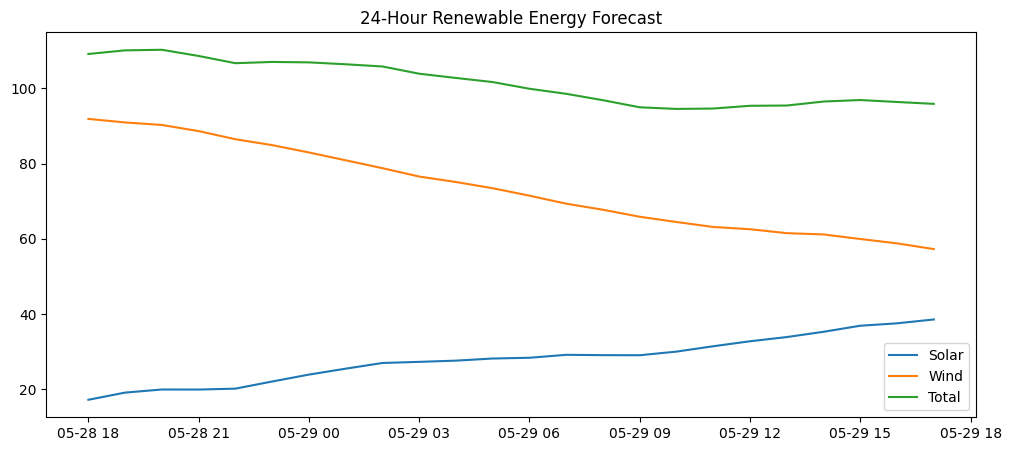

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(forecast_24h['timestamp'], forecast_24h['solar_pv_output'], label='Solar')
plt.plot(forecast_24h['timestamp'], forecast_24h['wind_power_output'], label='Wind')
plt.plot(forecast_24h['timestamp'], forecast_24h['total_renewable_energy'], label='Total')
plt.legend()
plt.title("24-Hour Renewable Energy Forecast")
plt.show()


### **Combined ML model**

In [80]:
solar_df.shape, wind_df.shape, df.shape

((3522, 40), (3522, 40), (3546, 26))

In [81]:
total_renewable_pred = y_pred_solar + y_pred_wind

In [82]:
total_renewable_pred.shape, y_pred_solar.shape, y_pred_wind.shape

((705,), (705,), (705,))

In [87]:
y_true_total = (
    test_solar['total_renewable_energy']
)

In [88]:
from sklearn.metrics import r2_score

r2 = r2_score(y_true_total, total_renewable_pred)
print("Total Renewable Energy R²:", r2)


Total Renewable Energy R²: 0.9988757011631133


In [89]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_true_total, total_renewable_pred))
mae  = mean_absolute_error(y_true_total, total_renewable_pred)
mse  = mean_squared_error(y_true_total, total_renewable_pred)

print("RMSE:", rmse)
print("MAE :", mae)
print("MAE :", mse)


RMSE: 1.4082066973867065
MAE : 1.111245786118827
MAE : 1.9830461025647748


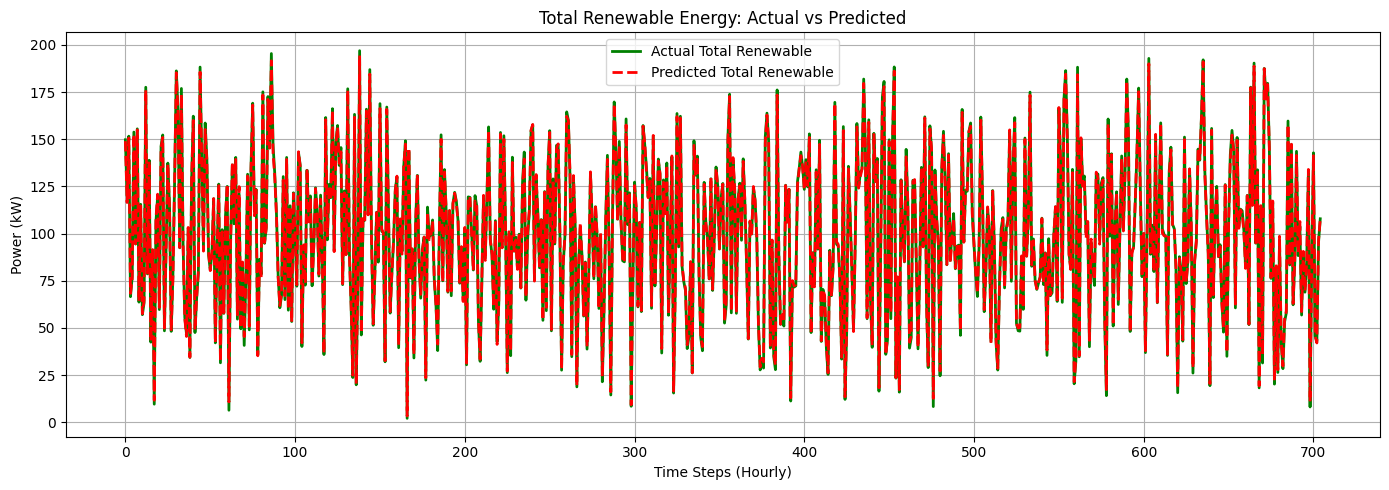

In [141]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure same length
min_len = min(len(y_true_total), len(total_renewable_pred))
# min_len=200

x = np.arange(min_len)

plt.figure(figsize=(14,5))

plt.plot(
    x,
    y_true_total.values[:min_len],
    label='Actual Total Renewable',
    color='green',
    linewidth=2
)

plt.plot(
    x,
    total_renewable_pred[:min_len],
    label='Predicted Total Renewable',
    color='red',
    linestyle='--',
    linewidth=2
)

plt.legend()
plt.title("Total Renewable Energy: Actual vs Predicted")
plt.xlabel("Time Steps (Hourly)")
plt.ylabel("Power (kW)")
plt.grid(True)

plt.tight_layout()
plt.show()


In [142]:
# plt.figure(figsize=(14,5))

# plt.plot(
#     y_true_total.index,
#     y_true_total.values,
#     label='Actual Total Renewable',
#     color='green',
#     linewidth=2
# )

# plt.plot(
#     y_true_total.index,
#     total_renewable_pred,
#     label='Predicted Total Renewable',
#     color='red',
#     linestyle='--',
#     linewidth=2
# )

# plt.legend()
# plt.title("Total Renewable Energy: Actual vs Predicted")
# plt.xlabel("Timestamp")
# plt.ylabel("Power (kW)")
# plt.grid(True)
# plt.show()


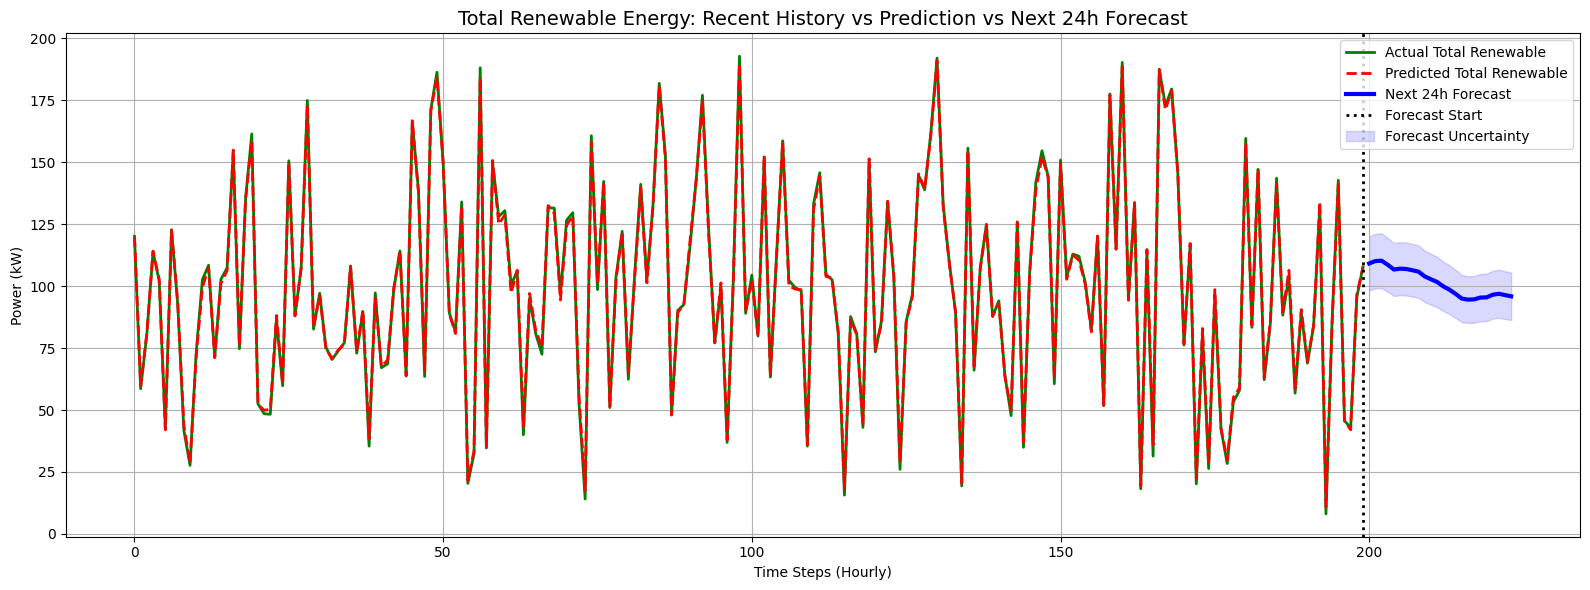

In [126]:
import matplotlib.pyplot as plt
import numpy as np

HISTORY_POINTS = 200

# Ensure we don't exceed available data
HISTORY_POINTS = min(HISTORY_POINTS, len(y_true_total))

# X-axis
hist_x = np.arange(HISTORY_POINTS)
future_x = np.arange(HISTORY_POINTS, HISTORY_POINTS + len(forecast_24h))

plt.figure(figsize=(16,6))

# Past actual (LAST 200)
plt.plot(
    hist_x,
    y_true_total.values[-HISTORY_POINTS:],
    label='Actual Total Renewable',
    color='green',
    linewidth=2
)

# Past predicted (LAST 200)
plt.plot(
    hist_x,
    total_renewable_pred[-HISTORY_POINTS:],
    label='Predicted Total Renewable',
    color='red',
    linestyle='--',
    linewidth=2
)

# Future forecast (NEXT 24)
plt.plot(
    future_x,
    forecast_24h['total_renewable_energy'].values,
    label='Next 24h Forecast',
    color='blue',
    linewidth=3
)

# Forecast boundary
plt.axvline(
    x=HISTORY_POINTS - 1,
    color='black',
    linestyle=':',
    linewidth=2,
    label='Forecast Start'
)

plt.fill_between(
    future_x,
    forecast_24h['total_renewable_energy'] * 0.9,
    forecast_24h['total_renewable_energy'] * 1.1,
    color='blue',
    alpha=0.15,
    label='Forecast Uncertainty'
)


plt.title(
    "Total Renewable Energy: Recent History vs Prediction vs Next 24h Forecast",
    fontsize=14
)
plt.xlabel("Time Steps (Hourly)")
plt.ylabel("Power (kW)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


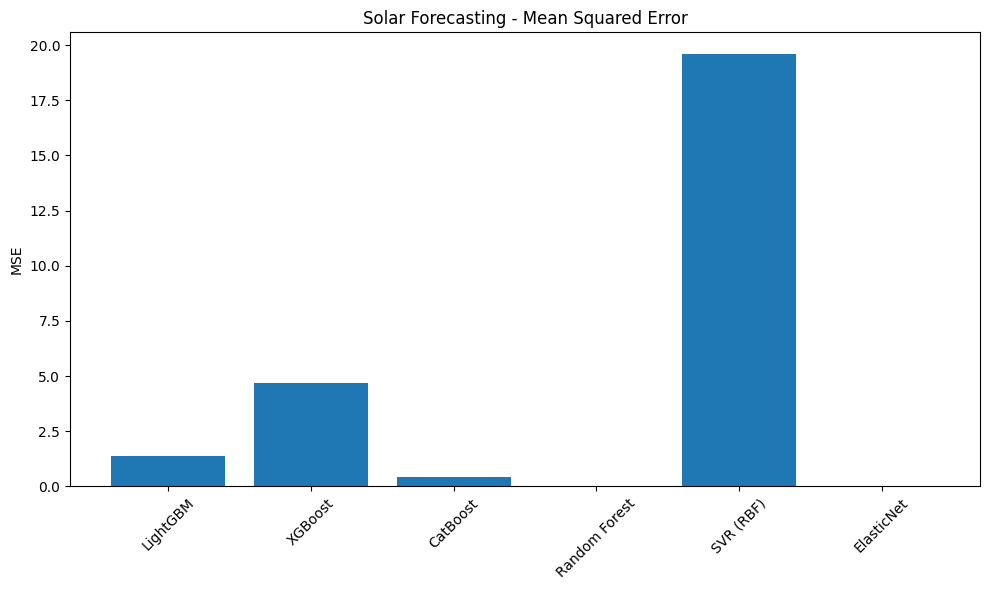

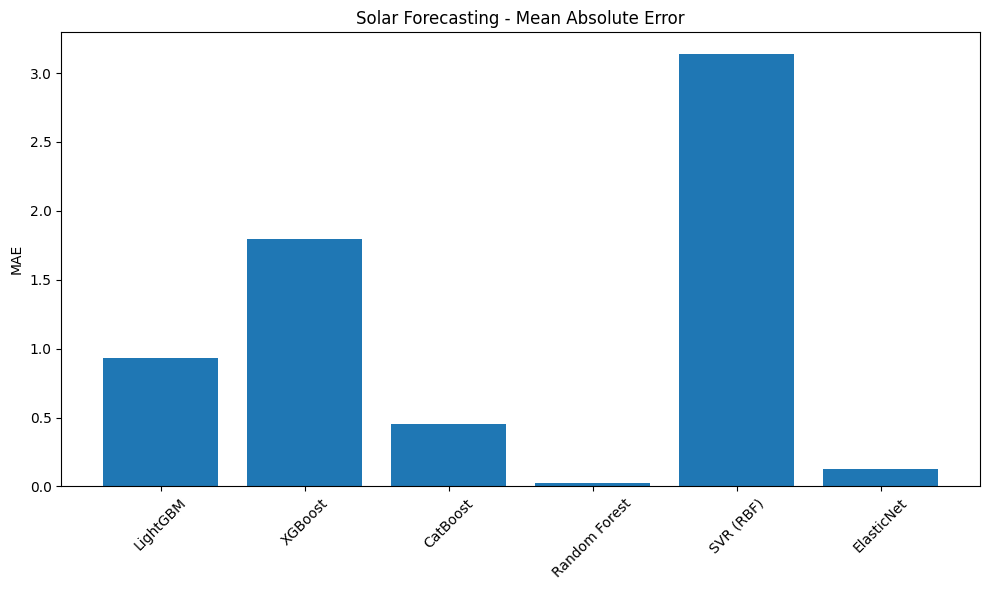

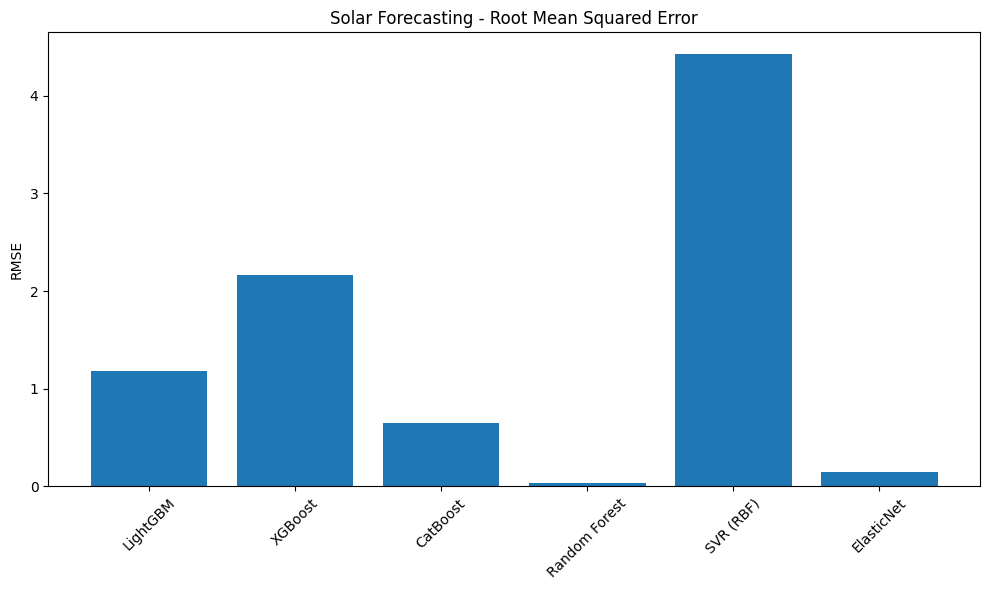

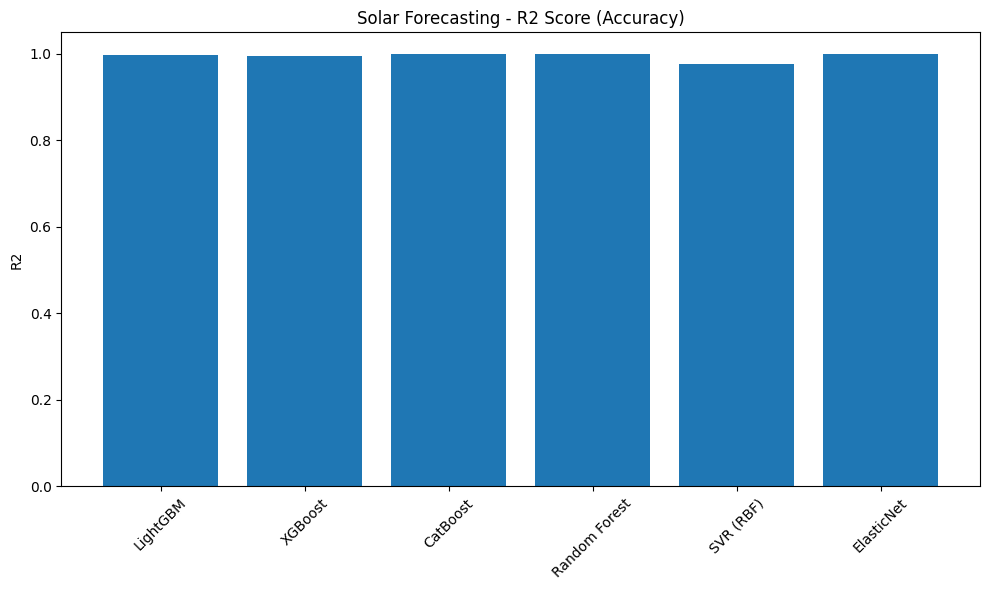

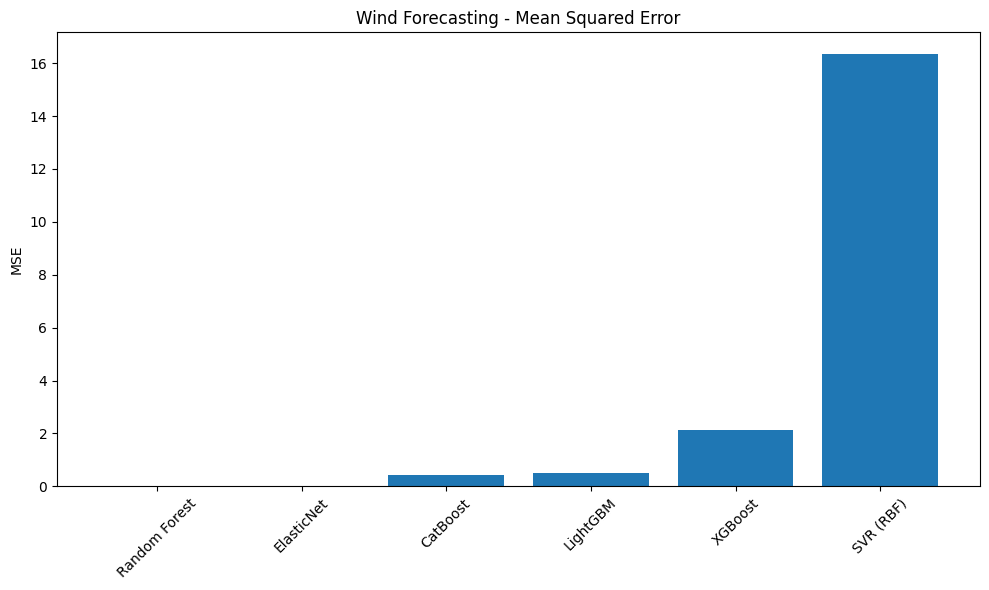

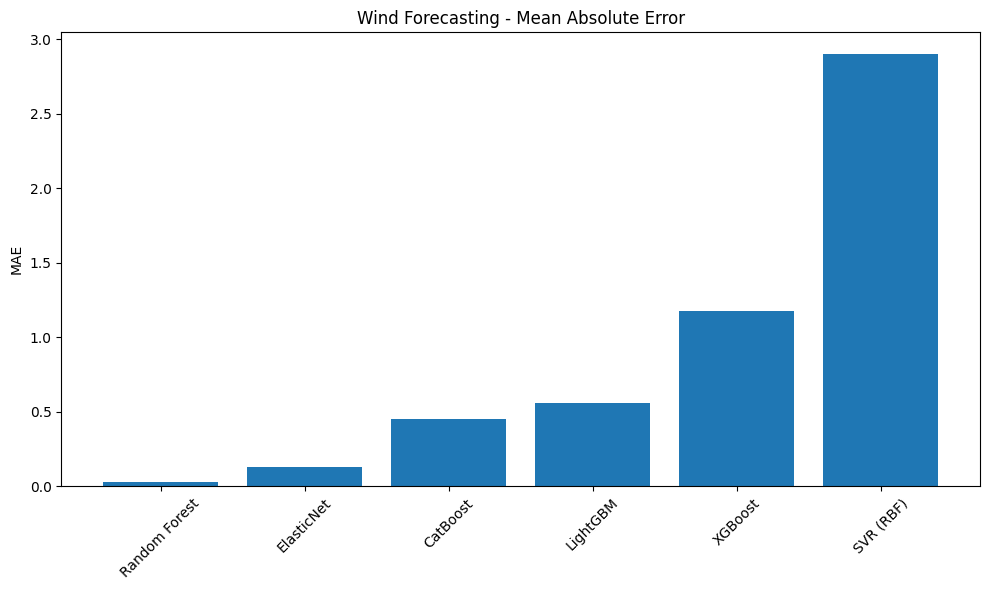

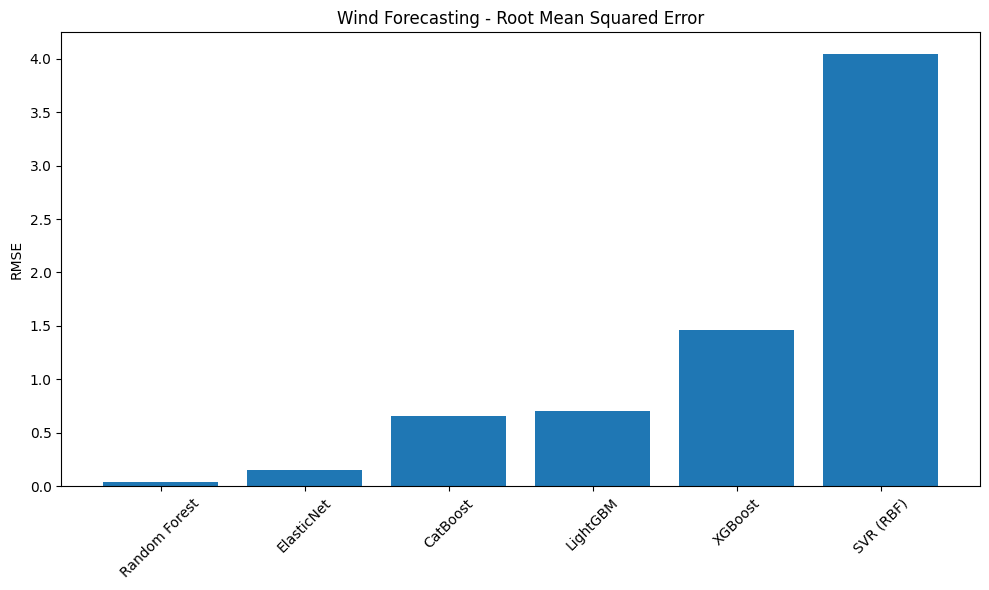

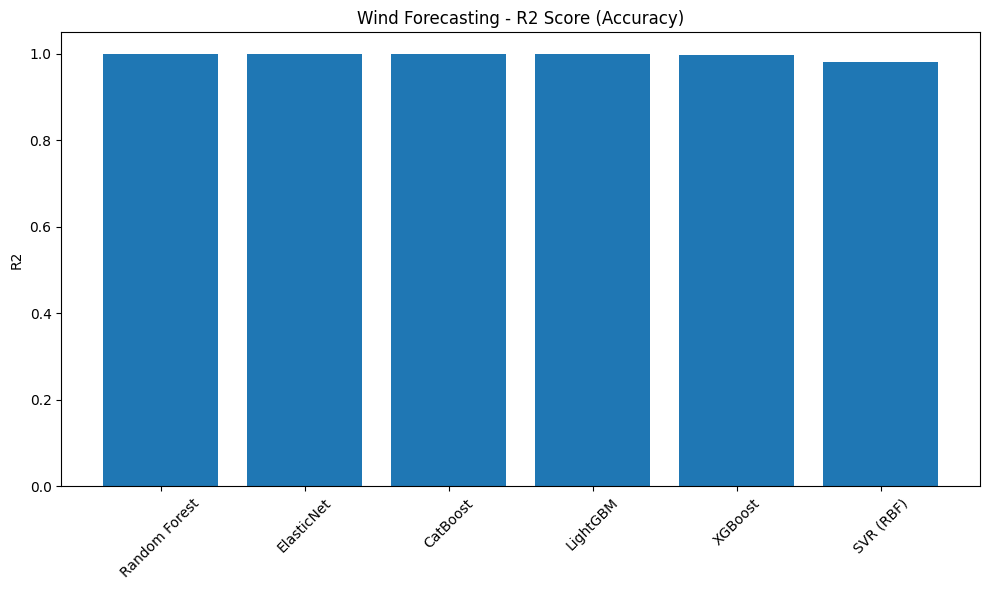

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -----------------------------
# Solar Results
# -----------------------------
solar_data = {
    "Model": ["LightGBM", "XGBoost", "CatBoost", "Random Forest", "SVR (RBF)", "ElasticNet"],
    "RMSE": [1.1818, 2.1622, 0.6487, 0.0389, 4.4270, 0.1481],
    "MAE":  [0.9347, 1.7987, 0.4525, 0.0270, 3.1384, 0.1298],
    "R2":   [0.998311, 0.994345, 0.999491, 0.999998, 0.976295, 0.999973]
}

solar_df = pd.DataFrame(solar_data)
solar_df["MSE"] = solar_df["RMSE"] ** 2


# -----------------------------
# Wind Results
# -----------------------------
wind_data = {
    "Model": ["Random Forest", "ElasticNet", "CatBoost", "LightGBM", "XGBoost", "SVR (RBF)"],
    "RMSE": [0.0381, 0.1493, 0.6590, 0.7059, 1.4652, 4.0433],
    "MAE":  [0.0282, 0.1289, 0.4495, 0.5576, 1.1760, 2.9020],
    "R2":   [0.999998, 0.999973, 0.999483, 0.999407, 0.997447, 0.980556]
}

wind_df = pd.DataFrame(wind_data)
wind_df["MSE"] = wind_df["RMSE"] ** 2


# ------------------------------------------
# Function to Plot and Save Bar Charts
# ------------------------------------------
def plot_metric(df, metric, title, filename):
    plt.figure(figsize=(10,6))
    plt.bar(df["Model"], df[metric])
    plt.xticks(rotation=45)
    plt.ylabel(metric)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()


# ------------------------------------------
# Solar Plots
# ------------------------------------------
plot_metric(solar_df, "MSE",  "Solar Forecasting - Mean Squared Error",  "solar_mse.png")
plot_metric(solar_df, "MAE",  "Solar Forecasting - Mean Absolute Error", "solar_mae.png")
plot_metric(solar_df, "RMSE", "Solar Forecasting - Root Mean Squared Error", "solar_rmse.png")
plot_metric(solar_df, "R2",   "Solar Forecasting - R2 Score (Accuracy)", "solar_r2.png")


# ------------------------------------------
# Wind Plots
# ------------------------------------------
plot_metric(wind_df, "MSE",  "Wind Forecasting - Mean Squared Error",  "wind_mse.png")
plot_metric(wind_df, "MAE",  "Wind Forecasting - Mean Absolute Error", "wind_mae.png")
plot_metric(wind_df, "RMSE", "Wind Forecasting - Root Mean Squared Error", "wind_rmse.png")
plot_metric(wind_df, "R2",   "Wind Forecasting - R2 Score (Accuracy)", "wind_r2.png")